In [1]:
%pip install --upgrade transformers==4.45.2 datasets accelerate trl==0.11.3 wandb evaluate tensorboard -q

Note: you may need to restart the kernel to use updated packages.


In [2]:
%pip install weave -q

Note: you may need to restart the kernel to use updated packages.


In [3]:
import os
import torch
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from pprint import pprint
import wandb
import evaluate
import weave

from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    AutoModelForSequenceClassification
)

from trl import (
    PPOConfig,
    PPOTrainer,
    AutoModelForCausalLMWithValueHead,
    DPOTrainer,
    DPOConfig
)

from torch.utils.tensorboard import SummaryWriter

/home/nam/projects/hoang/Advanced-ASM1/rlhf/lib/python3.13/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (7.1.0)/charset_normalizer (3.4.5) doesn't match a supported version!
  warnings.warn(
/home/nam/projects/hoang/Advanced-ASM1/rlhf/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
# ================= CONFIG =================

SEED = 42
MODEL_NAME = "gpt2"
BATCH_SIZE = 4
EPOCHS = 3
MAX_LENGTH = 256
MAX_NEW_TOKENS = 64
LR = 1e-5

EXP_NAME = "rlhf_full_experiment"

BASE_DIR = f"runs/{EXP_NAME}"
CKPT_DIR = f"{BASE_DIR}/checkpoints"
LOG_DIR = f"{BASE_DIR}/logs"
PLOT_DIR = f"{BASE_DIR}/plots"

os.makedirs(CKPT_DIR, exist_ok=True)
os.makedirs(LOG_DIR, exist_ok=True)
os.makedirs(PLOT_DIR, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [5]:
# ================= SEED =================

def seed_all(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_all(SEED)

In [6]:
# ================= LOGGING =================

wandb.init(
    project="rlhf-research",
    name=EXP_NAME,
    config=dict(
        model=MODEL_NAME,
        lr=LR,
        batch=BATCH_SIZE,
        epochs=EPOCHS
    )
)

tb_writer = SummaryWriter(LOG_DIR)

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/nam/.netrc.
wandb: Currently logged in as: hoang816528 (hoang-adelaide-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


wandb: Initializing weave.
weave: Logged in as Weights & Biases user: hoang816528.
weave: View Weave data at https://wandb.ai/hoang-adelaide-university/rlhf-research/weave


In [7]:
# ================= MODELS =================

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

policy_model = AutoModelForCausalLM.from_pretrained(MODEL_NAME).to(device)

reward_model = AutoModelForSequenceClassification.from_pretrained(
    "lvwerra/distilbert-imdb"
).to(device)

reward_tokenizer = AutoTokenizer.from_pretrained(
    "lvwerra/distilbert-imdb"
)

In [8]:
# ================= DATA =================

dataset = load_dataset("HumanLLMs/Human-Like-DPO-Dataset", split="train")
dataset = dataset.train_test_split(test_size=0.2, seed=SEED)

train_data = dataset["train"].select(range(2048))
val_data = dataset["test"].select(range(512))

In [9]:
# ================= ALIGNMENT METRICS =================

bleu = evaluate.load("bleu")
rouge = evaluate.load("rouge")
bertscore = evaluate.load("bertscore")

def compute_alignment(model, dataset, n=100):

    preds, refs = [], []
    n = min(n, len(dataset))

    for i in range(n):
        prompt = dataset[i]["prompt"]
        inputs = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=512).to(device)

        out = model.generate(**inputs, max_new_tokens=64, pad_token_id=tokenizer.pad_token_id)
        generated_tokens = out[0][len(inputs["input_ids"][0]):]
        text = tokenizer.decode(generated_tokens, skip_special_tokens=True).strip()

        if not text:
            continue

        preds.append(text)
        refs.append(dataset[i]["chosen"])

    if len(preds) == 0 or len(refs) == 0:
        return {"bleu": 0.0, "rouge": 0.0, "bertscore": 0.0}

    metrics = {}

    metrics["bleu"] = bleu.compute(
        predictions=preds,
        references=[[r] for r in refs]
    )["bleu"]

    metrics["rouge"] = rouge.compute(
        predictions=preds,
        references=refs
    )["rougeL"]

    bert = bertscore.compute(
        predictions=preds,
        references=refs,
        lang="en"
    )

    metrics["bertscore"] = float(np.mean(bert["f1"]))

    return metrics

In [10]:
# ================= LOGGER =================

class RLHFLogger:

    def __init__(self):
        self.history = []

    def log(self, step, reward, align=None, stats=None):

        row = dict(step=step, reward=reward)

        if align is not None:
            row.update(align)

        if stats is not None:
            row.update({f"ppo_{k}": v for k, v in stats.items()})

        self.history.append(row)

        wandb.log(row)
        tb_writer.add_scalar("reward", reward, step)

        if align is not None:
            for k, v in align.items():
                tb_writer.add_scalar(k, v, step)

    def df(self):
        return pd.DataFrame(self.history)

logger = RLHFLogger()

In [11]:
# ================= PPO =================

def preprocess_ppo(examples):
    tok = tokenizer(
        examples["prompt"],
        truncation=True,
        padding="max_length",
        max_length=MAX_LENGTH
    )
    return {
        "input_ids": tok["input_ids"],
        "query": examples["prompt"]
    }

ppo_dataset = train_data.map(
    preprocess_ppo,
    batched=True,
    remove_columns=train_data.column_names
)

Map: 100%|██████████| 2048/2048 [00:00<00:00, 8217.51 examples/s]


In [12]:
ppo_model = AutoModelForCausalLMWithValueHead.from_pretrained(MODEL_NAME)
ppo_model.to(device)

ppo_config = PPOConfig(
    model_name=MODEL_NAME,
    learning_rate=LR,
    batch_size=BATCH_SIZE,
    mini_batch_size=BATCH_SIZE//4,
    ppo_epochs=EPOCHS
)

ppo_trainer = PPOTrainer(
    config=ppo_config,
    model=ppo_model,
    tokenizer=tokenizer,
    dataset=ppo_dataset
)

generation_kwargs = dict(
    do_sample=True,
    top_p=0.95,
    max_new_tokens=MAX_NEW_TOKENS,
    pad_token_id=tokenizer.pad_token_id
)

/home/nam/projects/hoang/Advanced-ASM1/rlhf/lib/python3.13/site-packages/trl/trainer/ppo_config.py:207: FutureWarning: `PPOConfig` is deprecated and will be removed in the future. Please use `PPOv2Config` with `PPOv2Trainer` instead.
  warnings.warn(
/home/nam/projects/hoang/Advanced-ASM1/rlhf/lib/python3.13/site-packages/trl/trainer/ppo_trainer.py:193: FutureWarning: `PPOTrainer` is deprecated and will be removed in trl v0.12. Please use `PPOv2Trainer` instead.
  warnings.warn(


In [13]:
global_step = 0
eval_interval = 50
reward_running_mean = 0
reward_running_std = 1

for epoch in range(EPOCHS):

    for batch in tqdm(ppo_trainer.dataloader):

        queries_tensors = batch["input_ids"]
        queries_strings = batch["query"]

        responses = []
        rewards_list = []
        used_queries = []
        used_strings = []

        # ===== ROLLOUT =====
        for q_str, q_tensor in zip(queries_strings, queries_tensors):

            q_tensor = q_tensor.to(device)

            with torch.no_grad():
                r = ppo_trainer.generate(q_tensor, **generation_kwargs)

            response = r[0, q_tensor.shape[0]:]

            if len(response) == 0:
                continue

            responses.append(response)
            used_queries.append(q_tensor)
            used_strings.append(q_str)

        if len(responses) == 0:
            continue

        # ===== BUILD TEXT FOR REWARD =====
        texts = [
            q + tokenizer.decode(r, skip_special_tokens=True)
            for q, r in zip(used_strings, responses)
        ]

        reward_inputs = reward_tokenizer(
            texts,
            return_tensors="pt",
            padding=True,
            truncation=True
        ).to(device)

        with torch.no_grad():
            rewards = reward_model(**reward_inputs).logits[:, 1]

        # ===== REWARD NORMALIZATION (CRITICAL FOR PPO STABILITY) =====
        batch_mean = rewards.mean()
        batch_std = rewards.std() + 1e-6

        reward_running_mean = 0.9 * reward_running_mean + 0.1 * batch_mean.item()
        reward_running_std = 0.9 * reward_running_std + 0.1 * batch_std.item()

        rewards = (rewards - reward_running_mean) / reward_running_std

        rewards_list = [torch.tensor(r, device=device) for r in rewards]

        # ===== PPO STEP =====
        stats = ppo_trainer.step(
            used_queries,
            responses,
            rewards_list
        )

        mean_reward = torch.tensor(rewards_list).mean().item()

        # ===== SCHEDULED ALIGNMENT EVAL =====
        if global_step % eval_interval == 0:
            align = compute_alignment(
                ppo_trainer.model,
                val_data,
                50
            )
        else:
            align = None

        logger.log(global_step, mean_reward, align, stats)

        global_step += 1

    # ===== SAVE CHECKPOINT =====
    ppo_trainer.save_pretrained(f"{CKPT_DIR}/ppo_epoch_{epoch}")

  0%|          | 0/512 [00:00<?, ?it/s]The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
/tmp/ipykernel_1034468/3301577051.py:63: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  rewards_list = [torch.tensor(r, device=device) for r in rewards]
Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
  1%|▏         | 7/512 [00:48<37:11,  4.42s/it]  /home/nam/projects/hoang/Advanced-ASM1/rlhf/lib/python3.13/site-packages/trl/trainer/pp

KeyboardInterrupt: 

Error in callback <bound method _WandbInit._post_run_cell_hook of <wandb.sdk.wandb_init._WandbInit object at 0x7f1011846ba0>> (for post_run_cell), with arguments args (<ExecutionResult object at 7f0f210e1f10, execution_count=13 error_before_exec=None error_in_exec= info=<ExecutionInfo object at 7f0f3c3ba810, raw_cell="global_step = 0
eval_interval = 50
reward_running_.." transformed_cell="global_step = 0
eval_interval = 50
reward_running_.." store_history=True silent=False shell_futures=True cell_id=vscode-notebook-cell://ssh-remote%2B129.127.10.72/home/nam/projects/hoang/Advanced-ASM1/better_rlhf_trl.ipynb#X26sdnNjb2RlLXJlbW90ZQ%3D%3D> result=None>,),kwargs {}:


ConnectionResetError: Connection lost

In [ ]:
# ================= DPO =================

def preprocess_dpo(examples):
    chosen = [
        p + tokenizer.eos_token + c
        for p, c in zip(examples["prompt"], examples["chosen"])
    ]
    rejected = [
        p + tokenizer.eos_token + r
        for p, r in zip(examples["prompt"], examples["rejected"])
    ]
    return {"prompt": examples["prompt"], "chosen": chosen, "rejected": rejected}

dpo_train = train_data.map(preprocess_dpo, batched=True)
dpo_eval = val_data.map(preprocess_dpo, batched=True)

Map: 100%|██████████| 128/128 [00:00<00:00, 22973.64 examples/s]


In [ ]:
ref_model = AutoModelForCausalLM.from_pretrained(MODEL_NAME)

dpo_config = DPOConfig(
    output_dir=f"{CKPT_DIR}/dpo",
    learning_rate=LR,
    per_device_train_batch_size=BATCH_SIZE,
    num_train_epochs=EPOCHS
)

dpo_trainer = DPOTrainer(
    model=policy_model,
    ref_model=ref_model,
    args=dpo_config,
    train_dataset=dpo_train,
    eval_dataset=dpo_eval,
    tokenizer=tokenizer
)

dpo_trainer.train()

/home/nam/projects/hoang/Advanced-ASM1/rlhf/lib/python3.13/site-packages/trl/trainer/dpo_trainer.py:660: UserWarning: `max_length` is not set in the DPOConfig's init it will default to `512` by default, but you should do it yourself in the future.
  warnings.warn(
/home/nam/projects/hoang/Advanced-ASM1/rlhf/lib/python3.13/site-packages/trl/trainer/dpo_trainer.py:673: UserWarning: `max_prompt_length` is not set in the DPOConfig's init it will default to `128` by default, but you should do it yourself in the future.
  warnings.warn(
/home/nam/projects/hoang/Advanced-ASM1/rlhf/lib/python3.13/site-packages/trl/trainer/dpo_trainer.py:708: UserWarning: When using DPODataCollatorWithPadding, you should set `remove_unused_columns=False` in your TrainingArguments we have set it for you, but you should do it yourself in the future.
  warnings.warn(
Tokenizing eval dataset: 100%|██████████| 128/128 [00:00<00:00, 536.91 examples/s]
wandb: WARNING The `run_name` is currently set to the same value a

Step,Training Loss


TrainOutput(global_step=64, training_loss=0.035892222076654434, metrics={'train_runtime': 60.4949, 'train_samples_per_second': 8.464, 'train_steps_per_second': 1.058, 'total_flos': 0.0, 'train_loss': 0.035892222076654434, 'epoch': 1.0})

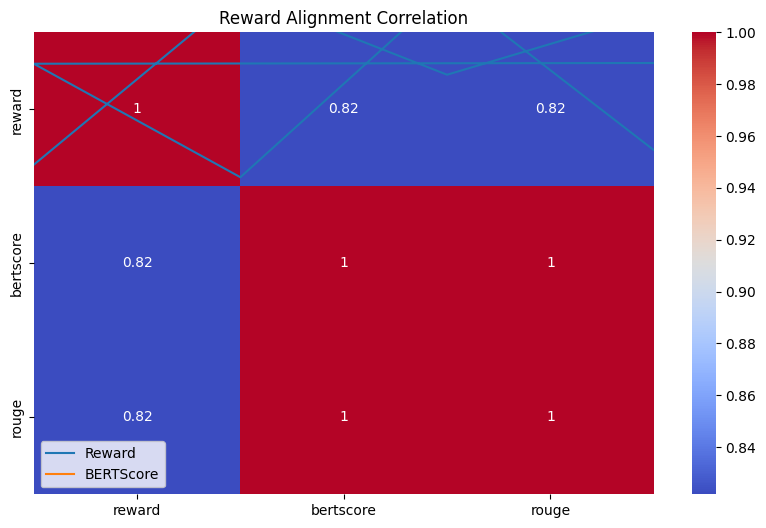

In [ ]:
# ================= PLOTS =================

df = logger.df()
df.to_csv(f"{LOG_DIR}/reward_alignment.csv", index=False)

plt.figure(figsize=(10,6))
plt.plot(df["step"], df["reward"], label="Reward")
plt.plot(df["step"], df["bertscore"], label="BERTScore")
plt.legend()
plt.title("Reward vs Alignment")
plt.savefig(f"{PLOT_DIR}/reward_alignment.png")

sns.heatmap(df[["reward","bertscore","rouge"]].corr(),
            annot=True, cmap="coolwarm")
plt.title("Reward Alignment Correlation")
plt.savefig(f"{PLOT_DIR}/correlation.png")

In [ ]:
# ================= FINAL =================

wandb.finish()
tb_writer.close()

wandb: ERROR The nbformat package was not found. It is required to save notebook history.


bertscore,█▁▁▁
bleu,█▁▁▁
ppo_objective/entropy,▇██▅▂▁▂▂▁▂▁▂▂▁▁▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
ppo_objective/kl,▁▃▂▃▂▅▆█▃▄▄▃▃▅▃▃▃▄▃▄▃▄▃▃▃▃▂▃▃▃▂▃▃▃▃▃▃▃▃▃
ppo_objective/kl_coef,▁▁▁▁▁▂▂▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▆▆▆▆▇▇▇▇▇███
ppo_ppo/learning_rate,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
ppo_ppo/loss/policy,▅▅▅▄▆▅▅▅▆█▁▅▁▅▆▅▃▄▃▄▃▆▅▄▂▅▄▅▅▅▄▅▆▄▅▅▄▅▅▅
ppo_ppo/loss/total,▇█▆▇█▁▃▂▁▃▂▂▃▂▆▄▂▄▄▄▁▃▁▃▂▅▁▂▂▂▄▃▂▂▂▁▂▃▂▃
ppo_ppo/loss/value,█▅▅▂▃▂▆▂▂▂▂▂▃▁▁▁▁▂▁▁▁▁▂▂▁▂▁▁▂▁▁▁▁▁▁▁▁▁▁▁
ppo_ppo/mean_non_score_reward,██████▇▇▅▆▆▇▇▆▇▆▆▆▇▆▅▆▅▄▅▄▄▄▅▆▄▄▃▄▃▃▁▂▂▂
+30,...
